In [1]:
import glob

data_root = "/datax/scratch/ktp/carmenes-lasers/spectra/extracted/"
dir_list = glob.glob(data_root + "/*")

diridx = 10

sci_list = glob.glob(dir_list[diridx] + "/*sci*.fits")
print(len(sci_list))

11


(61, 4096)


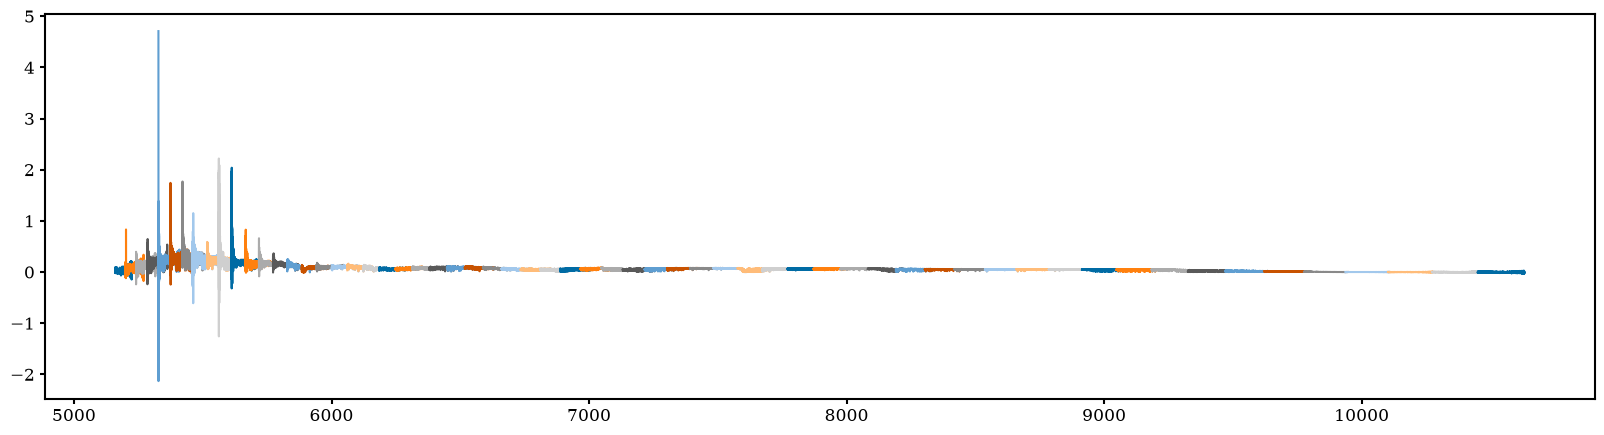

In [2]:
from astropy.io import fits
from figures import *
from load_data import *
    
spec, cont, sigma, wave, obj, ra, dec, date, exptime, airm = load_fits(sci_list[0], print_header=False)

print(wave.shape)

plt.figure(figsize=(20, 5))
for i, waveseg in enumerate(wave):
    plt.plot(waveseg, spec[i])


In [3]:
spec_arr, cont_arr, sigma_arr, wave, obj, ra, dec, date_arr, exptime_arr, airm_arr = load_star(dir_list[diridx])

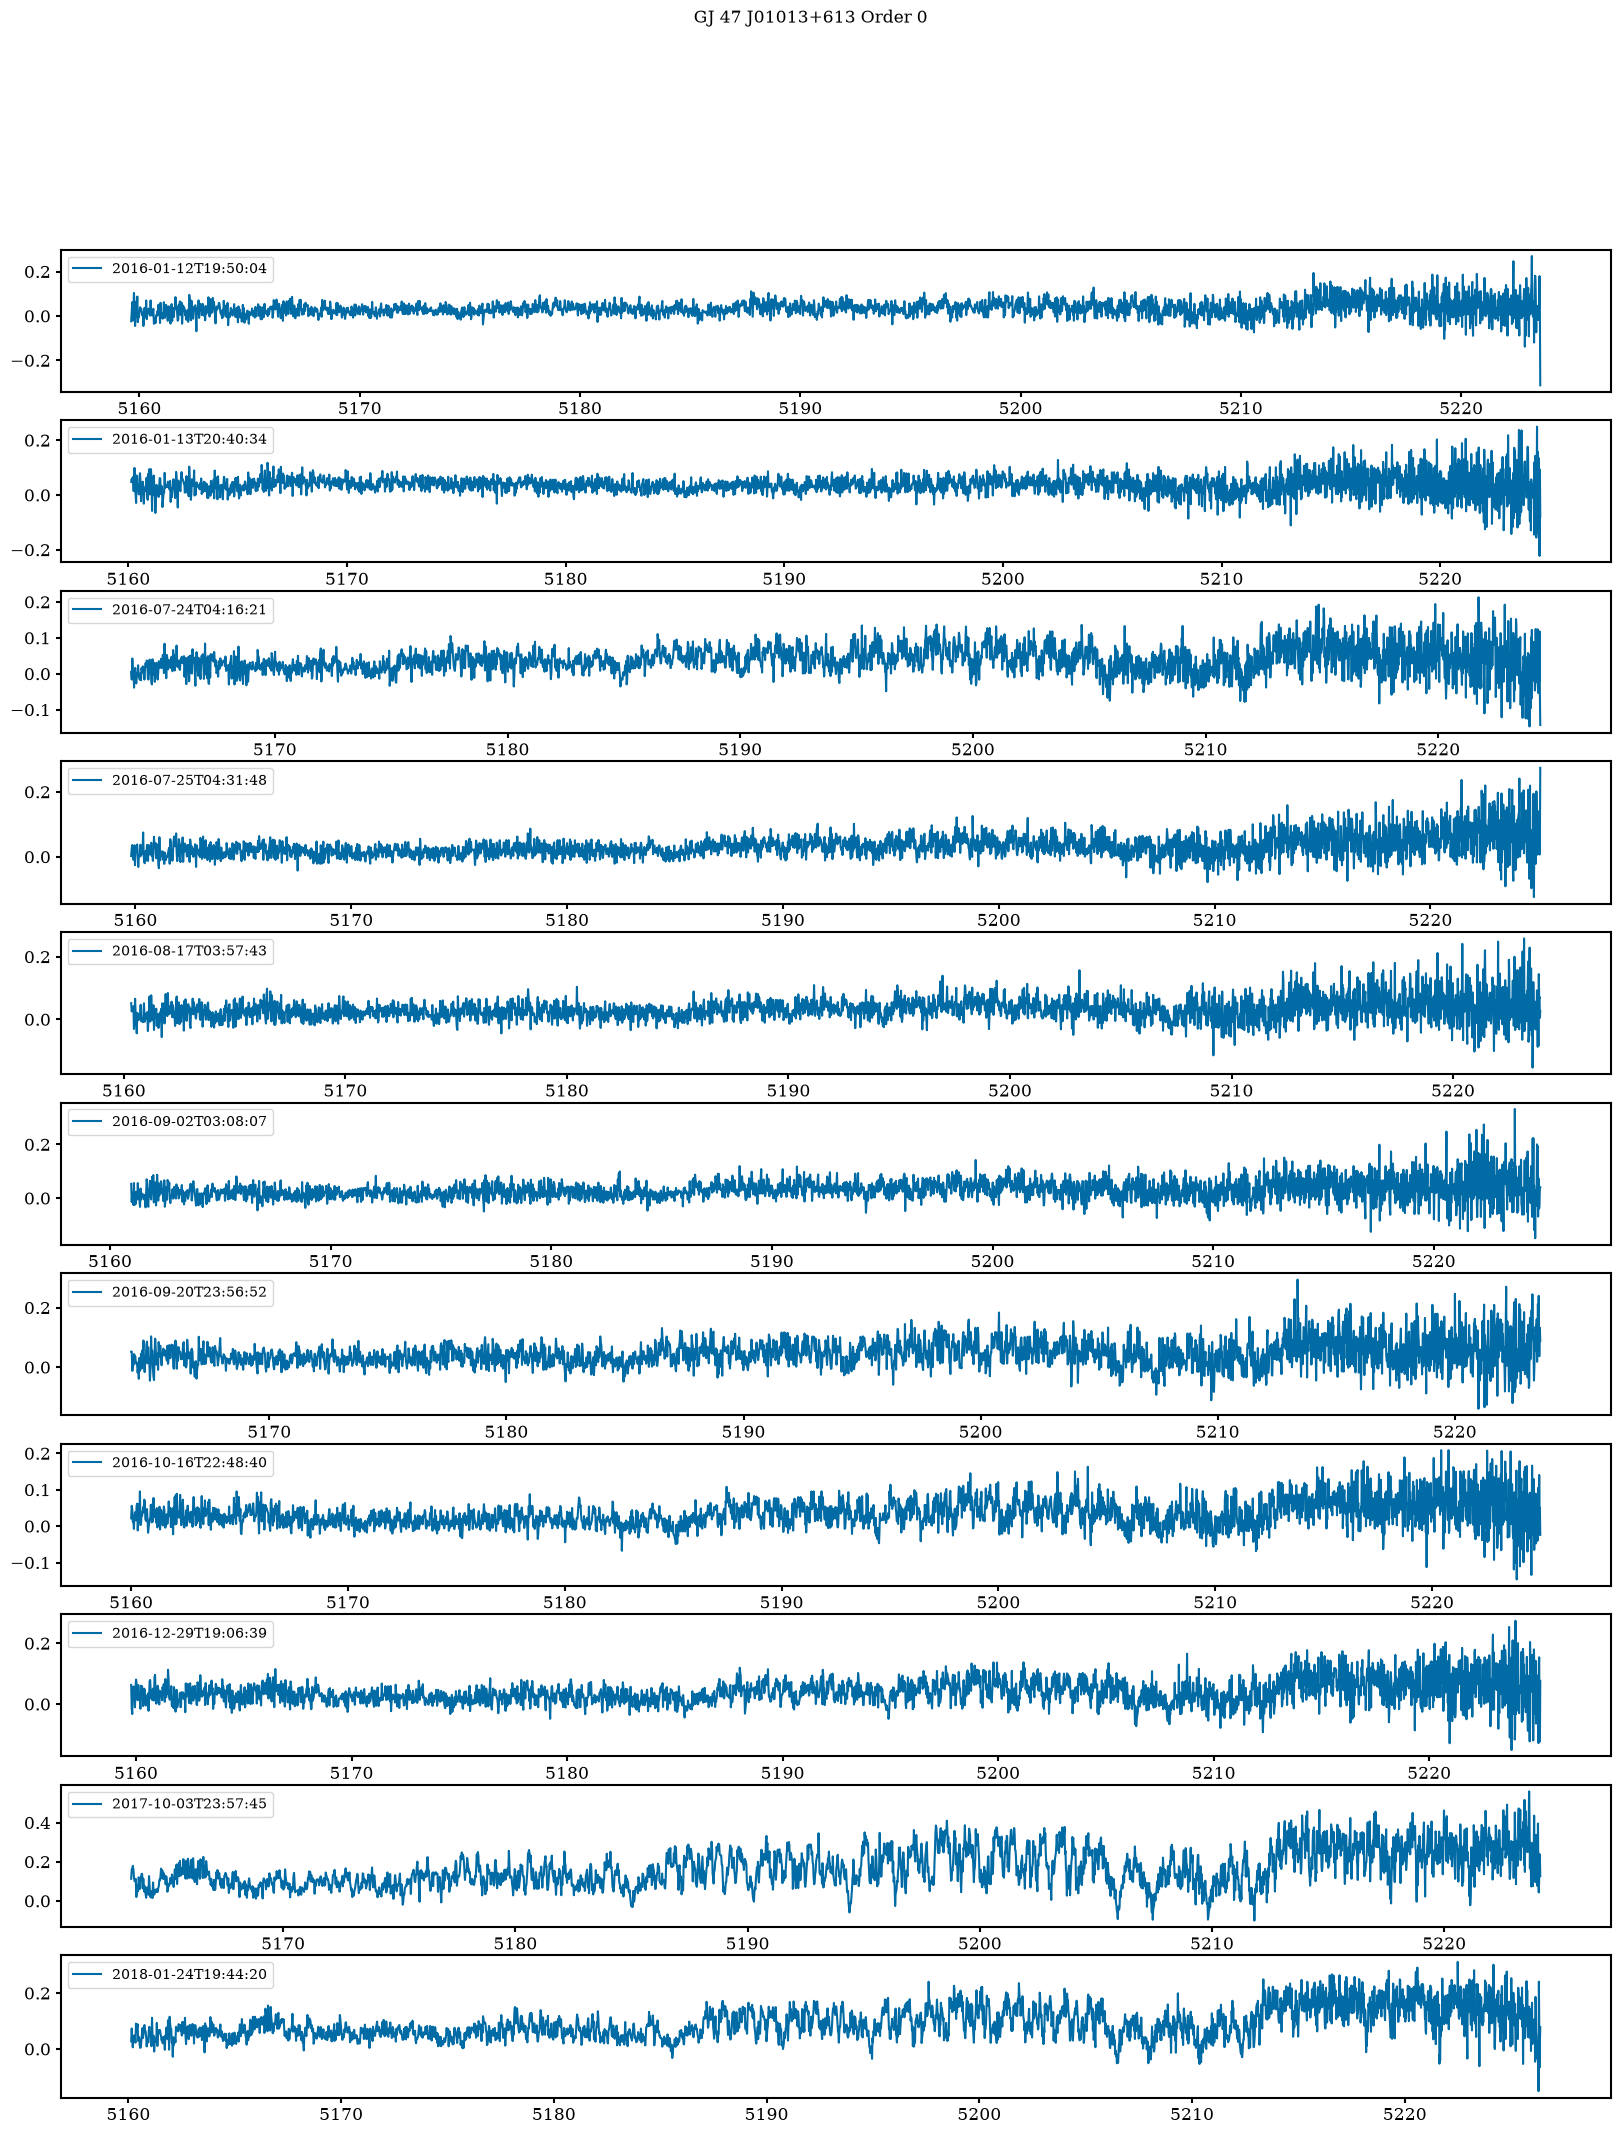

In [4]:
# spec_arr dims are ord, wav, obs
ordidx = 0
n_obs = spec_arr.shape[2]

fig, axs = plt.subplots(n_obs, figsize=(20, 24))
fig.suptitle(f"{obj} Order {ordidx}")
for i in range(n_obs):
    spectra = spec_arr[ordidx, :, i]   # first order, all wavelengths, obs i
    # do something with spectra, e.g.:
    axs[i].plot(wave[ordidx], spectra, label = f"{date_arr[i]}")
    axs[i].legend(loc="upper left")
